In [8]:
import seaborn as sns
import os
import sqlite3
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [9]:
import os
import json
import pandas as pd
import sqlite3

log_dir = "../data/merged_raw_data"       
db_path = "logs.db"

conn = sqlite3.connect(db_path)

for file in os.listdir(log_dir):
    if file.endswith(".log"):
        file_path = os.path.join(log_dir, file)
        all_logs = []

        # Read JSON lines
        with open(file_path, "r") as f:
            for line in f:
                line = line.strip()
                if line:  # skip empty lines
                    all_logs.append(json.loads(line))

        # Convert to DataFrame
        df = pd.DataFrame(all_logs)

        # Flatten list columns for SQLite
        for col in df.columns:
            if df[col].apply(lambda x: isinstance(x, list)).any():
                df[col] = df[col].apply(lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x)

        # Clean table name
        table_name = file.replace(".log", "").replace("-", "_")

        # Write to SQLite
        df.to_sql(table_name, conn, if_exists="replace", index=False)
        print(f"Loaded {file} → table `{table_name}`")


conn.close()


Loaded all-conn.log → table `all_conn`
Loaded all-dns.log → table `all_dns`
Loaded all-dpd.log → table `all_dpd`
Loaded all-files.log → table `all_files`
Loaded all-http.log → table `all_http`
Loaded all-kerberos.log → table `all_kerberos`
Loaded all-ntp.log → table `all_ntp`
Loaded all-packet_filter.log → table `all_packet_filter`
Loaded all-reporter.log → table `all_reporter`
Loaded all-sip.log → table `all_sip`
Loaded all-snmp.log → table `all_snmp`
Loaded all-tunnel.log → table `all_tunnel`
Loaded all-weird.log → table `all_weird`


In [11]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("logs.db")

for table in tables:
    print(f"Processing table {table}...")

    # Load table into pandas
    df = pd.read_sql(f"SELECT * FROM {table};", conn)

    if 'ts' in df.columns:
        # Sort by timestamp
        df = df.sort_values('ts')
        min_ts = df['ts'].min()

        # Integer bucket: each bucket = 1 minute from min_ts
        df['time_bucket_id'] = ((df['ts'] - min_ts) // 60).astype(int)

        # Replace table with updated version in SQLite
        df.to_sql(table, conn, if_exists="replace", index=False)
        print(f"Updated {table} with {len(df)} rows and time_bucket_id column")
    else:
        print(f"Table {table} has no 'ts' column; skipped")

conn.close()

Processing table all_conn...
Updated all_conn with 774766 rows and time_bucket_id column
Processing table all_dns...
Updated all_dns with 2347 rows and time_bucket_id column
Processing table all_dpd...
Updated all_dpd with 242 rows and time_bucket_id column
Processing table all_files...
Updated all_files with 26571 rows and time_bucket_id column
Processing table all_http...
Updated all_http with 28051 rows and time_bucket_id column
Processing table all_kerberos...
Updated all_kerberos with 10 rows and time_bucket_id column
Processing table all_ntp...
Updated all_ntp with 170 rows and time_bucket_id column
Processing table all_packet_filter...
Updated all_packet_filter with 5495 rows and time_bucket_id column
Processing table all_reporter...
Updated all_reporter with 3197 rows and time_bucket_id column
Processing table all_sip...
Updated all_sip with 31270 rows and time_bucket_id column
Processing table all_snmp...
Updated all_snmp with 810 rows and time_bucket_id column
Processing tabl

In [15]:
conn = sqlite3.connect("logs.db")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables = tables['name'].tolist()

plot_data = pd.DataFrame()

for table in tables:
    df = pd.read_sql(f"""
        SELECT time_bucket_id, COUNT(*) as msg_count
        FROM {table}
        GROUP BY time_bucket_id
    """, conn)
    
    df['log_type'] = table  
    plot_data = pd.concat([plot_data, df], ignore_index=True)

conn.close()
print(plot_data.head(10))

   time_bucket_id  msg_count  log_type
0               0          1  all_conn
1               1          2  all_conn
2               2          3  all_conn
3               3          4  all_conn
4               4          4  all_conn
5               5          3  all_conn
6               6          1  all_conn
7               7          3  all_conn
8               8          3  all_conn
9               9          3  all_conn


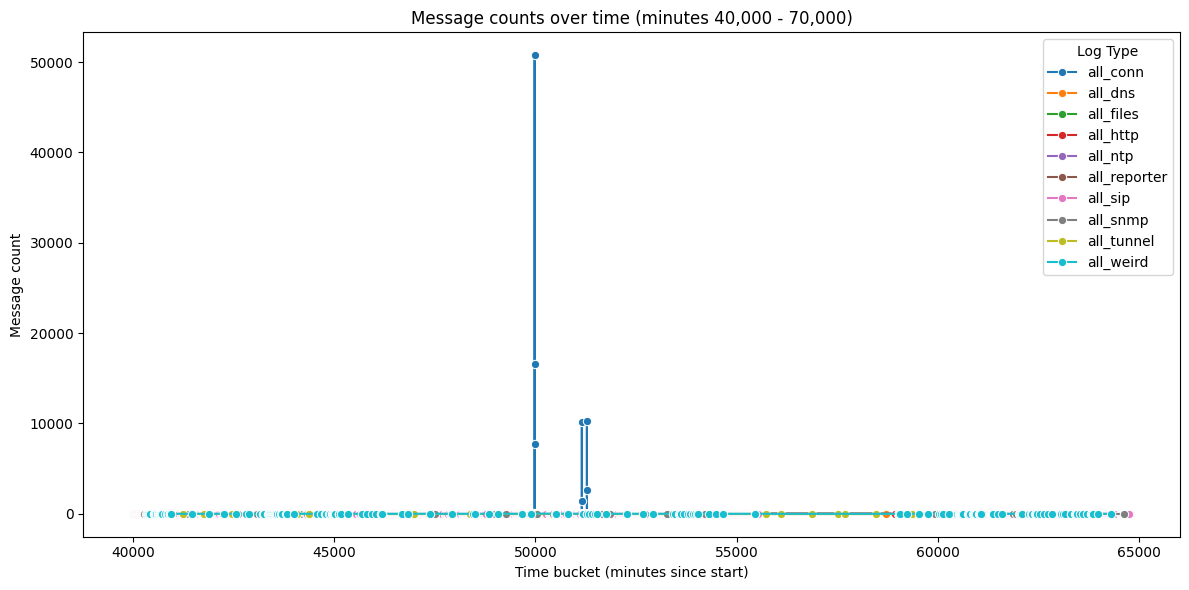

In [20]:
# Filter to the time window you want
zoomed_data = plot_data[
    (plot_data['time_bucket_id'] >= 40000) & 
    (plot_data['time_bucket_id'] <= 70000)
]

# Then plot the same way
plt.figure(figsize=(12,6))
sns.lineplot(
    data=zoomed_data,
    x='time_bucket_id',
    y='msg_count',
    hue='log_type',
    marker='o'
)

plt.title("Message counts over time (minutes 40,000 - 70,000)")
plt.xlabel("Time bucket (minutes since start)")
plt.ylabel("Message count")
plt.legend(title="Log Type")
plt.tight_layout()
plt.show()
